# Compile a function with jit

Runnable locally on CPU or on a Cloud TPU VM.

- Explain tracing, compilation, dispatch, and synchronization as separate work.
- Validate a compiled numerical function against its eager and analytic results.
- Measure first-call latency and repeated-call latency with explicit completion.
- Compile a value-and-gradient computation without claiming a universal speedup.

Your calculation is correct, and now you want to run it many times. What does compilation actually change? We’ll compare the original function with its jitted version, separate the first call from later calls, and wait for the result before stopping the timer. A small CPU example is enough to learn a fair comparison; a speedup is not guaranteed.

## The idea

Compilation prepares a program that can be reused for compatible calls. The first call can include tracing and compilation as well as execution; later compatible calls can reuse that work. Numerical equality and performance are separate checks.

## Separate changing data from preparing a program

Suppose you call a compiled function on a float32 vector, then call it on different values with the same shape and dtype. Those new values can flow through the prepared computation. If the next call changes a relevant shape or static choice, JAX may need a different specialization.

Think of the first-call path as preparation followed by execution. A warm-call timing should describe the repeated workload after preparation, and it must wait for device work to finish. Timing only dispatch can make a slow computation look fast.

First compare compiled and ordinary outputs on several inputs. Then, if speed is your question, state the input size, device, warmup and synchronization boundary. Three equal bars demonstrate agreement; they do not demonstrate acceleration.

### Pause and reason

Why can a tiny function be slower on its first compiled call?

<details><summary>Compare your reasoning</summary>

The call includes preparation costs that may exceed the work itself. Reuse can amortize those costs, but a speed claim still needs measurements of the intended workload.

</details>

## Separate the work hidden in one call

The first call can involve tracing, lowering, compilation, dispatch, and execution. Calling the same compiled function on compatible inputs can avoid much of the setup, but still involves a Python invocation, dispatch, and execution. A persistent cache or earlier compilation can also affect what first means.

Define the scope: first call to this callable in this process with these input shapes/dtypes. Do not label it cold-machine startup, pure compilation time, or kernel execution time unless your experiment actually isolates those quantities.

```text
first relevant call → trace / compile / dispatch / execute
compatible repeated call → reuse / dispatch / execute
```

## Check values before timing

Our input matrix has shape $(4, 3)$, weights have shape $(3,)$, and targets have shape $(4,)$. Predictions are $[0, 0.6, 1.2, 1.8]$. Residuals are $[-1, -0.4, 0.2, 0.8]$. Squaring and averaging yields $0.46$. Compute this independently so that two implementations agreeing on an unintended broadcast is not mistaken for correctness.

Compilation should preserve the intended numerical calculation within suitable tolerance. Floating-point transformations and reduction ordering can change last bits; exact equality is often too strong. Choose tolerance using dtype and scale, and do not suppress large discrepancies with a very loose allclose check.

## Wait for the quantity you are timing

JAX can return an array object while device computation is still pending. Timing only the Python call can therefore measure dispatch rather than completed work. block_until_ready waits for the array result without needing to print it or convert it to NumPy.

A function returning a tuple or a parameter tree needs a completion strategy for all relevant leaves. A scalar loss is convenient for this introductory experiment because waiting on it marks that result complete. Keep data creation and transfers outside the interval when measuring a prepared numerical invocation; include them deliberately when measuring end-to-end latency.

## Use repetitions and report a distribution

One repeated call is easy to distort with scheduling noise. Warm the exact callable and input signature, collect multiple completion-synchronized durations, and report a median plus range and repeat count. Use the same prepared arrays and comparable waiting behavior for eager and compiled calls.

This measures invocation latency under the stated conditions, including Python overhead. It is not a throughput measurement for queued training steps, and it does not isolate accelerator kernels. A median for a small toy workload cannot justify a performance claim about your future model or a different device.

## Compile the computation you intend to repeat

For training, loss and parameter gradients are often consumed together. `jit(value_and_grad(loss))` expresses a compiled transformed computation that returns both. Check the value against the loss and the gradient against an independent formula before using it as part of an update.

Avoid creating a fresh jitted lambda inside every iteration. Reusing a stable transformed callable gives compilation reuse a chance. A useful compilation boundary often surrounds a complete step rather than every scalar operation, but the correct boundary depends on the workload, state, and integration constraints. We will make state explicit before building that larger step.

## Decide when compilation is worth its setup

A long compilation can be worthwhile if a computation runs many times. A one-off small calculation might never recover its setup cost. You need both setup latency and steady-state measurements to reason about break-even behavior.

This lesson does not measure TPU execution, multi-device scaling, or a model training speedup. Its artifact is a reproducible correctness/timing report that records the backend, shapes, dtype, synchronization policy, warmup, repeat count, and observed durations.

## Run the example

In [1]:
# Compile a function with jit: Compilation prepares a program that can be reused for compatible...
# Import time for this computation.
import time
import jax
import jax.numpy as jnp
# Function `loss(w, x, y)` implementing this stage's computation:
def loss(w, x, y):
    # Return `jnp.mean((x @ w - y) ** 2)` to the caller.
    return jnp.mean((x @ w - y) ** 2)
# Construct and reshape `x` into the target tensor dimensions.
x = jnp.arange(12, dtype=jnp.float32).reshape(4, 3) / 10.
# Initialize array `w` with explicit values and shape.
w = jnp.array([1., 2., -1.])
# Initialize array `y` with explicit values and shape.
y = jnp.ones(4)
# Wrap with `jax.jit` (`compiled`) so XLA traces and compiles the function.
compiled = jax.jit(loss)
# Record execution timing or profiler trace in `t0`.
t0 = time.perf_counter()
# Synchronize host execution until asynchronous device computation completes.
first = compiled(w, x, y).block_until_ready()
# Record execution timing or profiler trace in `first_seconds`.
first_seconds = time.perf_counter() - t0
# Record execution timing or profiler trace in `t0`.
t0 = time.perf_counter()
# Synchronize host execution until asynchronous device computation completes.
second = compiled(w, x, y).block_until_ready()
# Record execution timing or profiler trace in `repeat_seconds`.
repeat_seconds = time.perf_counter() - t0
# Print diagnostic summary of the computed outputs.
print("Loss:", float(second))
# Print diagnostic summary of the computed outputs.
print("First/repeat seconds:", first_seconds, repeat_seconds)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(first, loss(w, x, y))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(second, first)

Loss: 0.46000000834465027
First/repeat seconds: 0.018300333060324192 2.2165942937135696e-05


Expected: Loss ≈ $0.46$. Timings depend on the device, process, and workload; no speed threshold is required.

## Compilation preserves the result

Predict: Should compilation change the loss value?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
# Compute figure data for: Compilation preserves the result
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'bar', 'labels': ['eager', 'first compiled', 'repeat compiled'], 'ylabel': 'mean squared loss', 'series': [{'label': 'evaluated loss', 'y': [float(loss(w, x, y)), float(first), float(second)]}]}

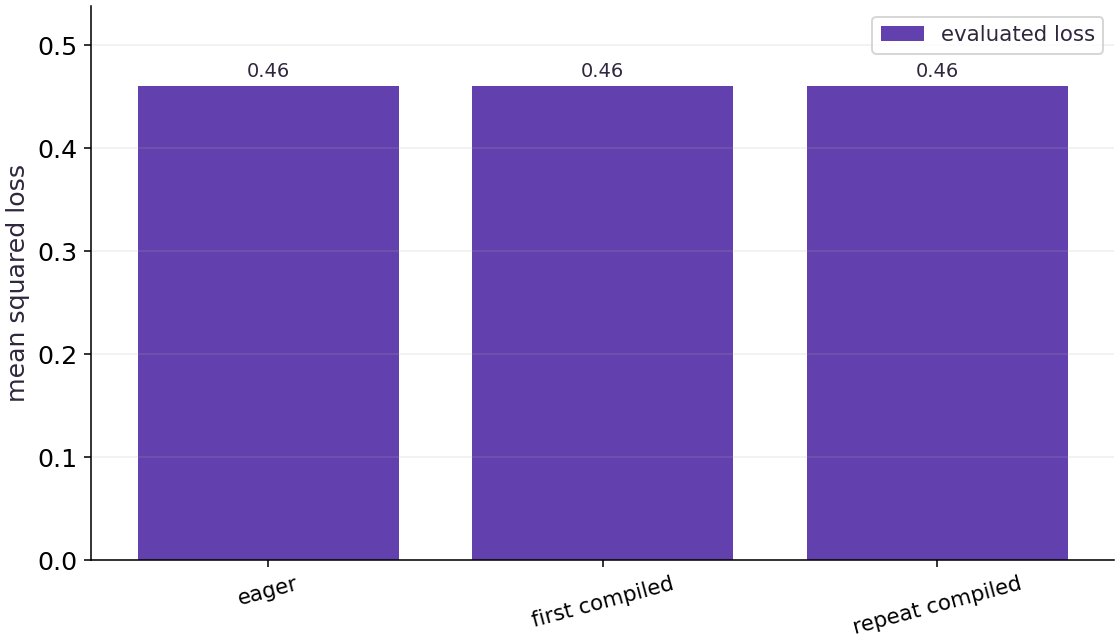

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The three categories are eager execution, the first compiled call, and a repeated compiled call. The vertical axis is mean squared loss. Each bar reaches approximately $0.46$, so all three execution paths return the same numerical result for this input.

These are separate bars with equal heights. The first compiled call has not disappeared, and its bar is not a measurement of compilation time.

### Connect it to the computation

Compilation changes how the computation runs while preserving its intended result. The agreement here is the correctness check to make before asking whether compilation improved performance. Small floating-point differences should be assessed with the example’s numerical tolerance.

To measure speed, you need a time axis, synchronization, warm-up, and repeated measurements. None of those can be inferred from these loss bars. A useful next check is to change the input values and confirm that eager and compiled results still agree.

## Derive predictions and gradients outside the transform

Predict: Predict the loss $0.46$ and derive $\frac{2}{N}X^\mathsf{T}(Xw-y)$. Does the compiled result match both independent quantities?

In [4]:
# Experiment — Derive predictions and gradients outside the transform: The analytic value check detects mistakes that...
# Initialize array `expected_predictions` with explicit values and shape.
expected_predictions = jnp.array([0., 0.6, 1.2, 1.8])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(x @ w, expected_predictions, atol=1e-6)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(compiled(w, x, y), 0.46, atol=1e-6)
# Perform matrix / vector contraction (`@`) to compute `manual_gradient`.
manual_gradient = (2. / len(y)) * x.T @ (x @ w - y)
# Differentiate the objective to obtain `compiled_value_gradient` via automatic differentiation.
compiled_value_gradient = jax.jit(jax.value_and_grad(loss))
# Run `compiled_value_gradient` to compute `(checked_value, checked_gradient)`.
checked_value, checked_gradient = compiled_value_gradient(w, x, y)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(checked_gradient, manual_gradient, rtol=1e-5, atol=1e-6)

Expected: The loss is $0.46$; the gradient matches the independent matrix expression.

The analytic value check detects mistakes that eager-versus-compiled equality alone would miss.

## Collect a synchronized latency sample

Predict: Which costs are included in these measurements? Predict whether the tiny compiled loss must be faster, then report what you actually observe.

In [5]:
# Experiment — Collect a synchronized latency sample: The report includes Python invocation and completed numerical...
# Import statistics for this computation.
import statistics
# Function `completed_samples(function, repeats)` implementing this stage's computation:
def completed_samples(function, repeats=20):
    # Synchronize host execution until asynchronous device computation completes.
    function(w, x, y).block_until_ready()
    # Evaluate `durations` from the current inputs and state.
    durations = []
    # Repeat the update loop over `range(repeats)` steps:
    for _ in range(repeats):
        # Record execution timing or profiler trace in `start`.
        start = time.perf_counter()
        # Synchronize host execution until asynchronous device computation completes.
        function(w, x, y).block_until_ready()
        # Record execution timing or profiler trace in ``.
        durations.append(time.perf_counter() - start)
    # Return `durations` to the caller.
    return durations
# Iterate over `(name, function)` to step through the computation:
for name, function in (("eager", loss), ("compiled", compiled)):
    # Run `completed_samples` to compute `samples`.
    samples = completed_samples(function)
    # Print the observed values to compare against the expected result.
    print(name, "median / min / max seconds:", statistics.median(samples), min(samples), max(samples))
# Print the observed values to compare against the expected result.
print("backend / shapes / dtype:", jax.default_backend(), x.shape, w.shape, y.shape, x.dtype)

eager median / min / max seconds: 3.0458439141511917e-05 2.970779314637184e-05 4.833284765481949e-05
compiled median / min / max seconds: 4.729023203253746e-06 4.582572728395462e-06 5.916692316532135e-06
backend / shapes / dtype: cpu (4, 3) (3,) (4,) float32


Expected: Twenty completed calls are measured after a warmup for each callable. Durations vary; no speed threshold is asserted.

The report includes Python invocation and completed numerical work on already prepared data. It is a bounded latency observation, not a universal accelerator benchmark.

## Your exercise

Foundation · Compile `value_and_grad(loss)`, check the loss and gradient against both the eager transform and the manual matrix formula, and explain how you would synchronize a benchmark of its two outputs.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.value_and_grad(loss_fn)(params, ...)` — Evaluates both the scalar loss and its gradient PyTree `(loss_val, grads)` in a single forward+backward pass.
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.

**Step-by-step implementation plan:**
1. Differentiate the objective to obtain `compiled_step` via automatic differentiation.
2. Run `compiled_step` to compute `(v, g)`.
3. Differentiate the objective to obtain `(expected_v, expected_g)` via automatic differentiation.
4. Verify that the numerical values match the expected reference within tolerance.
5. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Foundation · Compile value_and_grad(loss), check the loss and gradient...
# Differentiate the objective to obtain `compiled_step` via automatic differentiation.
compiled_step = jax.jit(...)  # TODO: compute compiled_step
# Run `compiled_step` to compute `(v, g)`.
v, g = compiled_step(...)  # TODO: compute v, g
# Differentiate the objective to obtain `(expected_v, expected_g)` via automatic differentiation.
expected_v, expected_g = jax.value_and_grad(...)  # TODO: compute expected_v, expected_g
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(v, expected_v)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(g, expected_g)  # TODO: complete assertion check
```

In [6]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Foundation · Compile value_and_grad(loss), check the loss and gradient...
# Differentiate the objective to obtain `compiled_step` via automatic differentiation.
# compiled_step = jax.jit(...)  # TODO: compute compiled_step
# Run `compiled_step` to compute `(v, g)`.
# v, g = compiled_step(...)  # TODO: compute v, g
# Differentiate the objective to obtain `(expected_v, expected_g)` via automatic differentiation.
# expected_v, expected_g = jax.value_and_grad(...)  # TODO: compute expected_v, expected_g
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(v, expected_v)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(g, expected_g)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [7]:
# Exercise solution: Foundation · Compile value_and_grad(loss), check the loss and gradient...
# Differentiate the objective to obtain `compiled_step` via automatic differentiation.
compiled_step = jax.jit(jax.value_and_grad(loss))
# Run `compiled_step` to compute `(v, g)`.
v, g = compiled_step(w, x, y)
# Differentiate the objective to obtain `(expected_v, expected_g)` via automatic differentiation.
expected_v, expected_g = jax.value_and_grad(loss)(w, x, y)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(v, expected_v)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(g, expected_g)

## Check that a new value remains runtime data · Practice

Keep shapes and dtypes fixed, change $w$, and compare the compiled loss against an independently computed residual mean. Explain why a different numerical answer does not itself imply a new compilation.

Hint: Compilation specializes to relevant properties, not each ordinary array element value.

### How to write: Check that a new value remains runtime data — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Iterate over `new_w` to step through the computation:
2. Aggregate array values to compute `expected`.
3. Run `compiled` to compute `observed`.
4. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Check that a new value remains runtime data (Practice): The same computation accepts different runtime values.
# Iterate over `new_w` to step through the computation:
for new_w in (w, w + 0.25):
    # Aggregate array values to compute `expected`.
    expected = jnp.mean(...)  # TODO: compute expected
    # Run `compiled` to compute `observed`.
    observed = compiled(...)  # TODO: compute observed
    # Verify that the numerical values match the expected reference within tolerance.
    assert jnp.allclose(observed, expected, rtol=1e-5, atol=1e-6)  # TODO: complete assertion check
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check that a new value remains runtime data (Practice): The same computation accepts different runtime values.
# Iterate over `new_w` to step through the computation:
# for new_w in (w, w + 0.25):
    # Aggregate array values to compute `expected`.
#     expected = jnp.mean(...)  # TODO: compute expected
    # Run `compiled` to compute `observed`.
#     observed = compiled(...)  # TODO: compute observed
    # Verify that the numerical values match the expected reference within tolerance.
#     assert jnp.allclose(observed, expected, rtol=1e-5, atol=1e-6)  # TODO: complete assertion check

## Reference reasoning

The same computation accepts different runtime values. The next lesson inspects tracing explicitly rather than inferring it from timing noise.

In [9]:
# Check that a new value remains runtime data (Practice): The same computation accepts different runtime values.
# Iterate over `new_w` to step through the computation:
for new_w in (w, w + 0.25):
    # Aggregate array values to compute `expected`.
    expected = jnp.mean((x @ new_w - y) ** 2)
    # Run `compiled` to compute `observed`.
    observed = compiled(new_w, x, y)
    # Verify that the numerical values match the expected reference within tolerance.
    assert jnp.allclose(observed, expected, rtol=1e-5, atol=1e-6)

## Build a report whose timing claim can be checked · Challenge

Benchmark the compiled value-and-gradient function for $20$ calls after warmup, waiting on every output leaf. Include backend, input shapes, dtype, and median. State what your measurement excludes.

Hint: Use `jax.tree.map` to block on every returned array, then stop the timer.

### How to write: Build a report whose timing claim can be checked — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jax.tree.map(lambda p, g: ..., params, grads)` — Applies a function leaf-by-leaf across matching PyTrees (such as updating every parameter tensor with its gradient).
- `jax.block_until_ready(output)` — Synchronizes with the accelerator/CPU device so asynchronous dispatch finishes before wall-clock timing.

**Step-by-step implementation plan:**
1. Return `jax.tree.map(lambda array: array.block_until_ready(), outputs)` to the caller.
2. Run `wait_for_outputs` to perform the next check or state transition.
3. Evaluate `gradient_times` from the current inputs and state.
4. Repeat the update loop over `range(20)` steps:
5. Record execution timing or profiler trace in `started`.

**Starter code scaffold (fill in the TODOs):**

```python
# Build a report whose timing claim can be checked (Challenge): The measurement excludes input construction and first...
def wait_for_outputs(outputs):
    # Return `jax.tree.map(lambda array: array.block_until_ready(), outputs)` to the caller.
    return ...  # TODO: return computed result
# Run `wait_for_outputs` to perform the next check or state transition.
wait_for_outputs(compiled_value_gradient(w, x, y))
# Evaluate `gradient_times` from the current inputs and state.
gradient_times = ...  # TODO: compute gradient_times
# Repeat the update loop over `range(20)` steps:
for _ in range(20):
    # Record execution timing or profiler trace in `started`.
    started = time.perf_counter(...)  # TODO: compute started
    # Run `wait_for_outputs` to perform the next check or state transition.
    wait_for_outputs(compiled_value_gradient(w, x, y))
    # Record execution timing or profiler trace in ``.
    gradient_times.append(time.perf_counter() - started)
# Print the observed values to compare against the expected result.
print("compiled value-and-grad median seconds:", statistics.median(gradient_times))
# Verify contract: `len(gradient_times) == 20`.
assert len(gradient_times)  # TODO: complete assertion check
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Build a report whose timing claim can be checked (Challenge): The measurement excludes input construction and first...
# def wait_for_outputs(outputs):
    # Return `jax.tree.map(lambda array: array.block_until_ready(), outputs)` to the caller.
#     return ...  # TODO: return computed result
# Run `wait_for_outputs` to perform the next check or state transition.
# wait_for_outputs(compiled_value_gradient(w, x, y))
# Evaluate `gradient_times` from the current inputs and state.
# gradient_times = ...  # TODO: compute gradient_times
# Repeat the update loop over `range(20)` steps:
# for _ in range(20):
    # Record execution timing or profiler trace in `started`.
#     started = time.perf_counter(...)  # TODO: compute started
    # Run `wait_for_outputs` to perform the next check or state transition.
#     wait_for_outputs(compiled_value_gradient(w, x, y))
    # Record execution timing or profiler trace in ``.
#     gradient_times.append(time.perf_counter() - started)
# Print the observed values to compare against the expected result.
# print("compiled value-and-grad median seconds:", statistics.median(gradient_times))
# Verify contract: `len(gradient_times) == 20`.
# assert len(gradient_times)  # TODO: complete assertion check

## Reference reasoning

The measurement excludes input construction and first compilation, and includes repeated invocation and completion. It cannot be compared with another report without matching those boundaries.

In [11]:
# Build a report whose timing claim can be checked (Challenge): The measurement excludes input construction and first...
def wait_for_outputs(outputs):
    # Return `jax.tree.map(lambda array: array.block_until_ready(), outputs)` to the caller.
    return jax.tree.map(lambda array: array.block_until_ready(), outputs)
# Run `wait_for_outputs` to perform the next check or state transition.
wait_for_outputs(compiled_value_gradient(w, x, y))
# Evaluate `gradient_times` from the current inputs and state.
gradient_times = []
# Repeat the update loop over `range(20)` steps:
for _ in range(20):
    # Record execution timing or profiler trace in `started`.
    started = time.perf_counter()
    # Run `wait_for_outputs` to perform the next check or state transition.
    wait_for_outputs(compiled_value_gradient(w, x, y))
    # Record execution timing or profiler trace in ``.
    gradient_times.append(time.perf_counter() - started)
# Print the observed values to compare against the expected result.
print("compiled value-and-grad median seconds:", statistics.median(gradient_times))
# Verify contract: `len(gradient_times) == 20`.
assert len(gradient_times) == 20

compiled value-and-grad median seconds: 9.292270988225937e-06


## Checkpoint

Why wait with block_until_ready when timing a computation?

1. To change its gradient
2. To include completion of device work in elapsed time
3. To force a different result

## Diagnose

A suspiciously tiny time may measure dispatch only; inspect synchronization. A slow first call followed by faster calls may reflect setup, but timing alone does not identify which setup stage. Inconsistent eager/compiled results call for shape, dtype, and tolerance checks before performance tuning. Repeatedly slow setup can come from recreating transformed functions or changing specialization inputs; the next lesson tests those hypotheses directly.

## Evidence

Keep the independent loss/gradient calculation, backend/shapes/dtype, first-call interval, warmup/repeat policy, median/range samples, and synchronization of every output leaf. State what the benchmark excludes.

## Carry forward

- Compilation setup and repeated invocation are different measurements.
- Correctness needs independent numerical checks before performance interpretation.
- Asynchronous execution requires completion synchronization.
- A useful report records workload, backend, dtype, warmup, repetitions, and timing boundaries.

## Primary references

- [JAX: just-in-time compilation](https://docs.jax.dev/en/latest/jit-compilation.html)
- [JAX: benchmarking](https://docs.jax.dev/en/latest/benchmarking.html)